LİBRARY

In [39]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms , datasets
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA PREPARATİON

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [31]:
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [32]:
train_loader = DataLoader(train_set, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_set, batch_size = 64, shuffle = False)

DATA VİSUALİZATİON

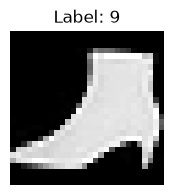

In [33]:
images, labels = next(iter(train_loader))
img = images[0].numpy().squeeze()
plt.figure(figsize=(2,2))
plt.imshow(img, cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()

MODEL DEFİNE

In [34]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.Flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.Flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

MODEL TRAİNİNG

In [35]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    training_losses = []
    for epoch in range(num_epochs):
        run_loss = 0
        for images,labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
        avg_loss = run_loss / len(train_loader)
        training_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    plt.figure()
    plt.plot(range(1, num_epochs+1), training_losses, marker='o')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

MODEL TEST

In [36]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0   
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            _, predicted = torch.max(out.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Epoch [1/15], Loss: 0.5125
Epoch [2/15], Loss: 0.3794
Epoch [3/15], Loss: 0.3422
Epoch [4/15], Loss: 0.3160
Epoch [5/15], Loss: 0.2970
Epoch [6/15], Loss: 0.2820
Epoch [7/15], Loss: 0.2697
Epoch [8/15], Loss: 0.2565
Epoch [9/15], Loss: 0.2442
Epoch [10/15], Loss: 0.2366
Epoch [11/15], Loss: 0.2277
Epoch [12/15], Loss: 0.2180
Epoch [13/15], Loss: 0.2125
Epoch [14/15], Loss: 0.2033
Epoch [15/15], Loss: 0.1973


C:\Users\Emirhan\AppData\Local\Temp\ipykernel_51804\776515502.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


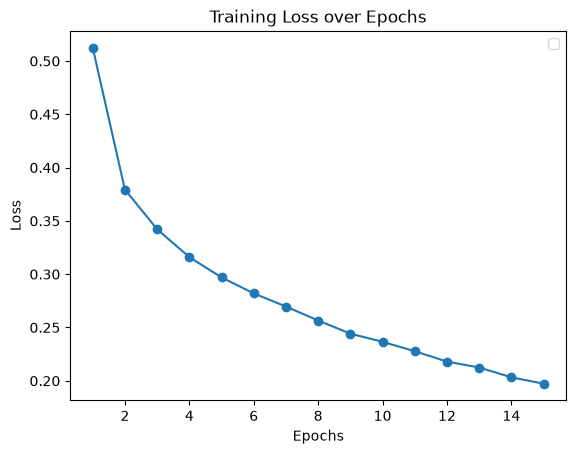

Accuracy of the model on the test images: 87.46%


In [38]:
if __name__ == "__main__":
    model = ANN().to(device)
    criterion, optimizer = nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=0.001)
    train_model(model, train_loader, criterion, optimizer, num_epochs=15)
    test_model(model, test_loader)
    
